In [1]:
from pathlib import Path
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path('../PS3/02_Datasets/SHM')
TRAIN_DIR = DATA_DIR / 'Train'
LABEL_PATH = DATA_DIR / 'Train_Labels.csv'
TRAIN_FILES = sorted(TRAIN_DIR.glob('train*.csv'))
print('Train directory:', TRAIN_DIR)
print('Training files found:', len(TRAIN_FILES))
print('Labels found:', LABEL_PATH.exists())

Train directory: C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\SHM\Train
Training files found: 64
Labels found: True


In [2]:
labels = pd.read_csv(LABEL_PATH)
labels.columns = labels.columns.str.strip()
labels['filename'] = labels['filename'].astype(str)
labels['damage'] = pd.to_numeric(labels['damage'], errors='coerce')
file_table = pd.DataFrame({'filename': [p.name for p in TRAIN_FILES]})
file_table = file_table.merge(labels, on='filename', how='left', indicator=True)
print('Label rows:', len(labels))
print('Training files without labels:', (file_table['_merge'] != 'both').sum())
print('Labels without files:', (~labels['filename'].isin(file_table['filename'])).sum())
if file_table['damage'].isna().any():
    raise ValueError('Every training file must have a numeric damage label.')
display(file_table.head())
display(file_table['damage'].describe())

Label rows: 64
Training files without labels: 0
Labels without files: 0


,filename,damage,_merge
0,train01.csv,0.103663,both
1,train02.csv,0.149209,both
2,train03.csv,0.111298,both
3,train04.csv,0.894736,both
4,train05.csv,0.054740,both


count    64.000000
mean      0.230147
std       0.263480
min       0.028620
25%       0.045889
50%       0.098931
75%       0.387633
max       0.928339
Name: damage, dtype: float64

In [3]:
def inspect_signal_file(path, sample_rows=3):
    values = []
    row_count = 0
    missing_count = 0
    minimum = np.inf
    maximum = -np.inf
    total = 0.0
    total_sq = 0.0
    first_rows = []
    last_rows = []
    with open(path, newline='', encoding='utf-8-sig') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        for row in reader:
            row_count += 1
            if len(first_rows) < sample_rows: first_rows.append(row)
            last_rows = (last_rows + [row])[-sample_rows:]
            try:
                x = float(row[0])
                if not np.isfinite(x): missing_count += 1
                else:
                    minimum = min(minimum, x); maximum = max(maximum, x)
                    total += x; total_sq += x*x
            except (ValueError, IndexError):
                missing_count += 1
    mean = total / max(row_count - missing_count, 1)
    variance = max(total_sq / max(row_count - missing_count, 1) - mean*mean, 0)
    return {'filename': path.name, 'header': header, 'rows': row_count, 'missing_or_invalid': missing_count, 'min': minimum, 'max': maximum, 'mean': mean, 'std': np.sqrt(variance), 'first_rows': first_rows, 'last_rows': last_rows}

# Inspect a few requested files first.
for path in TRAIN_FILES[:3]:
    info = inspect_signal_file(path)
    print(info['filename'], 'rows=', info['rows'], 'header=', info['header'], 'mean=', info['mean'], 'std=', info['std'])
    print('first:', info['first_rows'][:2], 'last:', info['last_rows'][-2:])

train01.csv rows= 581119 header= ['-0.17716719'] mean= 5.93508735525458 std= 8.63142384580031
first: [['-1.1784055'], ['-0.17716719']] last: [['8.313854'], ['8.760294']]
train02.csv rows= 581119 header= ['0.24129'] mean= -7.732041671033933 std= 10.753985486178093
first: [['-0.30294117'], ['-0.41348812']] last: [['-12.284531'], ['-12.178235']]
train03.csv rows= 581119 header= ['-1.4971671'] mean= 1.92678905927689 std= 9.019787526703245
first: [['-0.5192518'], ['-0.08556759']] last: [['1.7512126'], ['1.4238235']]


In [4]:
# Build a compact per-file metadata table. Only one file is held in memory at a time.
summaries = []
for path in TRAIN_FILES:
    info = inspect_signal_file(path)
    summaries.append({k: info[k] for k in ['filename','rows','missing_or_invalid','min','max','mean','std']})

summary = pd.DataFrame(summaries).merge(file_table[['filename','damage']], on='filename', how='left')
display(summary.head())
display(summary[['rows','missing_or_invalid','min','max','mean','std','damage']].describe())
print('Distinct row counts:', summary['rows'].nunique())
print('Distinct headers are checked in the next cell.')

,filename,rows,missing_or_invalid,min,max,mean,std,damage
0,train01.csv,581119,0,-19.343730,39.391250,5.935087,8.631424,0.103663
1,train02.csv,581119,0,-37.650806,25.297182,-7.732042,10.753985,0.149209
2,train03.csv,581119,0,-28.079456,29.944937,1.926789,9.019788,0.111298
3,train04.csv,581119,0,-54.097850,38.489470,-2.477910,6.969857,0.894736
4,train05.csv,581119,0,-19.364319,29.429405,3.074603,8.830389,0.054740


,rows,missing_or_invalid,min,max,mean,std,damage
count,64.0,64.0,64.000000,64.000000,64.000000,64.000000,64.000000
mean,581119.0,0.0,-32.958205,29.848766,-0.980908,7.504331,0.230147
std,0.0,0.0,11.919798,9.105004,4.263356,3.422899,0.263480
min,581119.0,0.0,-61.633114,14.461987,-13.866898,2.432371,0.028620
25%,581119.0,0.0,-37.255788,22.992438,-3.380303,4.274916,0.045889
50%,581119.0,0.0,-31.175038,28.483382,-0.617678,7.958808,0.098931
75%,581119.0,0.0,-24.491997,34.049674,2.255238,10.046449,0.387633
max,581119.0,0.0,-13.069520,60.196007,7.935486,16.033114,0.928339


Distinct row counts: 1
Distinct headers are checked in the next cell.


In [5]:
headers = {}
for path in TRAIN_FILES:
    with open(path, newline='', encoding='utf-8-sig') as handle:
        headers[path.name] = tuple(next(csv.reader(handle)))
print('Unique header patterns:', len(set(headers.values())))
for header, count in pd.Series(list(headers.values())).value_counts().items():
    print(count, header)

if summary['missing_or_invalid'].sum() > 0:
    print('Warning: invalid signal values were found.')
else:
    print('No invalid signal values found in the training files.')

Unique header patterns: 60
2 ('0.350774',)
2 ('-0.46716717',)
2 ('0.1775129',)
2 ('0.040923633',)
1 ('-0.17716719',)
1 ('-0.4097678',)
1 ('-0.8721517',)
1 ('-1.3871517',)
1 ('-0.38319403',)
1 ('0.67975754',)
1 ('-0.058993805',)
1 ('-0.46238387',)
1 ('-0.001594427',)
1 ('-1.9850619',)
1 ('0.7610733',)
1 ('0.49002066',)
1 ('1.3334727',)
1 ('-1.1643188',)
1 ('0.9407121',)
1 ('2.0366151',)
1 ('0.3401445',)
1 ('1.1612744',)
1 ('-0.08668731',)
1 ('1.0353148',)
1 ('0.70048505',)
1 ('-0.53997934',)
1 ('0.9444324',)
1 ('-0.59897316',)
1 ('1.2968009',)
1 ('1.3095562',)
1 ('1.4992931',)
1 ('-1.9462643',)
1 ('0.6861352',)
1 ('0.24129',)
1 ('-1.4971671',)
1 ('-0.0568679',)
1 ('-0.7616047',)
1 ('0.4273065',)
1 ('-0.2633127',)
1 ('1.2734159',)
1 ('3.414732',)
1 ('1.6491693',)
1 ('-0.24182147',)
1 ('0.79455626',)
1 ('-0.92795664',)
1 ('1.1708411',)
1 ('0.4756708',)
1 ('-0.19133127',)
1 ('1.1469246',)
1 ('1.2170794',)
1 ('1.5136429',)
1 ('-3.0527968',)
1 ('1.7267647',)
1 ('-1.3164654',)
1 ('1.4737822',

Damage range: 0.028620288 to 0.928338975
Damage median: 0.098930746


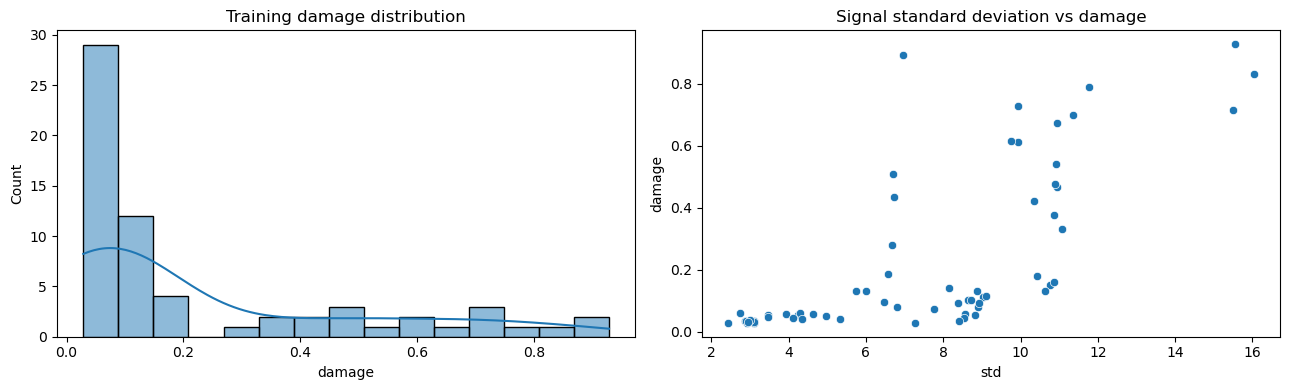

In [6]:
print('Damage range:', labels['damage'].min(), 'to', labels['damage'].max())
print('Damage median:', labels['damage'].median())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(labels['damage'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Training damage distribution')
sns.scatterplot(data=summary, x='std', y='damage', ax=axes[1])
axes[1].set_title('Signal standard deviation vs damage')
plt.tight_layout(); plt.show()

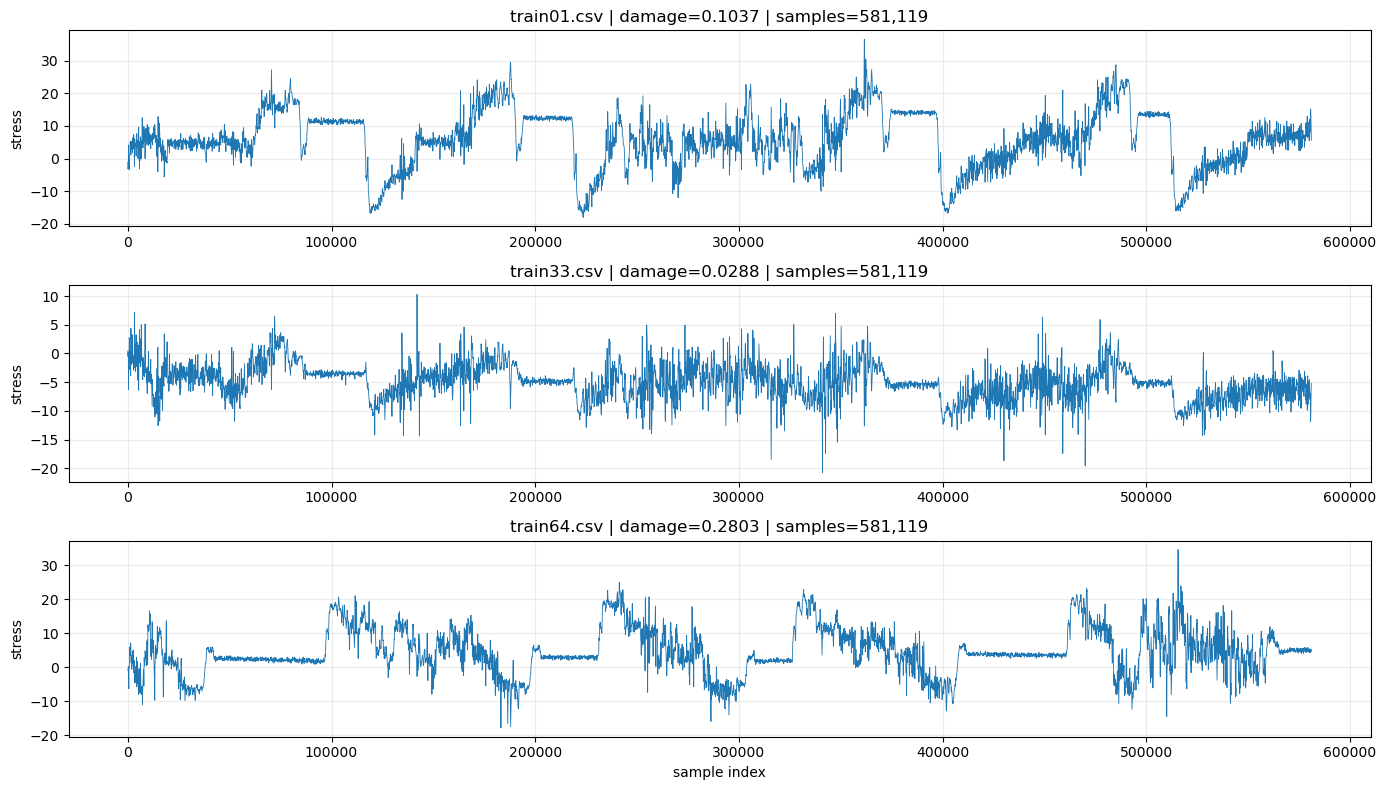

In [7]:
def load_signal(path):
    return pd.read_csv(path, usecols=[0]).iloc[:, 0].to_numpy(dtype=float)

representatives = [TRAIN_FILES[0], TRAIN_FILES[len(TRAIN_FILES)//2], TRAIN_FILES[-1]]
fig, axes = plt.subplots(len(representatives), 1, figsize=(14, 8), sharex=False)
axes = np.atleast_1d(axes)
for ax, path in zip(axes, representatives):
    signal = load_signal(path)
    step = max(len(signal)//5000, 1)
    ax.plot(np.arange(0, len(signal), step), signal[::step], linewidth=.6)
    damage = file_table.loc[file_table['filename'].eq(path.name), 'damage'].iloc[0]
    ax.set_title(f'{path.name} | damage={damage:.4f} | samples={len(signal):,}')
    ax.set_ylabel('stress')
    ax.grid(alpha=.25)
axes[-1].set_xlabel('sample index'); plt.tight_layout(); plt.show()

In [8]:
summary['file_number'] = summary['filename'].str.extract(r'(\d+)').astype(int)
summary = summary.sort_values('filename').reset_index(drop=True)
summary.to_csv('shm_eda_file_summary.csv', index=False)
display(summary.sort_values('damage', ascending=False).head(10))
print('Saved compact metadata:', Path('shm_eda_file_summary.csv').resolve())
print('Next step: create per-file time-series features, then evaluate regression with grouped or repeated validation.')

,filename,rows,missing_or_invalid,min,max,mean,std,damage,file_number
30,train31.csv,581119,0,-61.633114,33.649857,-13.866898,15.550468,0.928339,31
3,train04.csv,581119,0,-54.097850,38.489470,-2.477910,6.969857,0.894736,4
53,train54.csv,581119,0,-53.751335,36.620808,-4.151601,16.033114,0.832608,54
22,train23.csv,581119,0,-49.762604,43.288166,4.420357,11.766271,0.789624,23
56,train57.csv,581119,0,-54.748380,32.719772,-4.180767,9.927065,0.728839,57
9,train10.csv,581119,0,-51.528698,36.998150,-3.144718,15.500449,0.716510,10
33,train34.csv,581119,0,-47.729713,43.152645,2.258981,11.352500,0.700104,34
26,train27.csv,581119,0,-46.995743,44.426590,2.618634,10.947339,0.672913,27
51,train52.csv,581119,0,-58.136540,26.325588,-7.762403,9.741900,0.616001,52
15,train16.csv,581119,0,-55.697060,28.331377,-6.395625,9.942532,0.612026,16


Saved compact metadata: C:\Users\limju\Documents\AY2627\Semester 1\Hackathon\shm_eda_file_summary.csv
Next step: create per-file time-series features, then evaluate regression with grouped or repeated validation.
